In [1]:
## test1
from bigrams import BIGRAM_BAG

print(len(BIGRAM_BAG))
print(BIGRAM_BAG[:5])

40
['th', 'he', 'in', 'er', 'an']


In [2]:
## test2
from text_processing import count_tracked_bigrams, counts_to_vector

sentence = "The queen quickly quit the quiet quiz"
counts = count_tracked_bigrams(sentence)
print(counts)

vector = counts_to_vector(counts)
print(vector)

Counter({'th': 2, 'he': 2, 'en': 1, 'ic': 1, 'it': 1})
[2. 2. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]


In [3]:
## test 3
from typing_env import TypingEnv

env = TypingEnv()
env.reset()

for _ in range(5):
    state, reward, _, _ = env.step(0)
    print("Reward:", reward)

Avg skill before: 0.25392515409827376
Avg skill after : 0.26532701979196627
Reward: 0.11021724128336817
Avg skill before: 0.26532701979196627
Avg skill after : 0.2733677507151991
Reward: 0.09776533720406519
Avg skill before: 0.2733677507151991
Avg skill after : 0.2825675510944943
Reward: 0.05943337630583753
Avg skill before: 0.2825675510944943
Avg skill after : 0.2879405180461676
Reward: -0.05086714040690288
Avg skill before: 0.2879405180461676
Avg skill after : 0.2926971501196623
Reward: -0.11263816079317943


In [4]:
## test 4
env.sample_sentence(0,1)

'the truth is that the earth breathes through its rhythm'

### we can see the skill growing, as we ran 5 iterations, and rewards are positive.

In [5]:
## test 5
env = TypingEnv()
state = env.reset()

for _ in range(5):
    action = 0  # same bigram
    state, reward, _, _ = env.step(action)
    print("Reward:", reward)
    print("Skill:", env.k[0])

Avg skill before: 0.25620233293389594
Avg skill after : 0.263886961580976
Reward: 0.13756273808464817
Skill: 0.30983065381228664
Avg skill before: 0.263886961580976
Avg skill after : 0.2679348994530459
Reward: 0.04806332547066269
Skill: 0.3769810305779637
Avg skill before: 0.2679348994530459
Avg skill after : 0.2739573461284688
Reward: 0.006773566415080229
Skill: 0.42163303609678926
Avg skill before: 0.2739573461284688
Avg skill after : 0.2769615446851236
Reward: -0.014010830544128605
Skill: 0.5045365948377699
Avg skill before: 0.2769615446851236
Avg skill after : 0.2823612293668666
Reward: -0.07385334928641402
Skill: 0.5688117460771491


### Forgetting Curve

Avg skill before: 0.24789333351272633
Avg skill after : 0.270223846281666
Avg skill before: 0.270223846281666
Avg skill after : 0.288794746605969
Avg skill before: 0.288794746605969
Avg skill after : 0.30294462751110307
Avg skill before: 0.30294462751110307
Avg skill after : 0.3193908001659508
Avg skill before: 0.3193908001659508
Avg skill after : 0.33544824118998917
Avg skill before: 0.33544824118998917
Avg skill after : 0.35518221441958153
Avg skill before: 0.35518221441958153
Avg skill after : 0.37221785213264535
Avg skill before: 0.37221785213264535
Avg skill after : 0.3824630043045369
Avg skill before: 0.3824630043045369
Avg skill after : 0.39993935057630664
Avg skill before: 0.39993935057630664
Avg skill after : 0.4166584990707406
Avg skill before: 0.4166584990707406
Avg skill after : 0.4296738341798962
Avg skill before: 0.4296738341798962
Avg skill after : 0.4451679847833109
Avg skill before: 0.4451679847833109
Avg skill after : 0.4535341197435928
Avg skill before: 0.45353411974

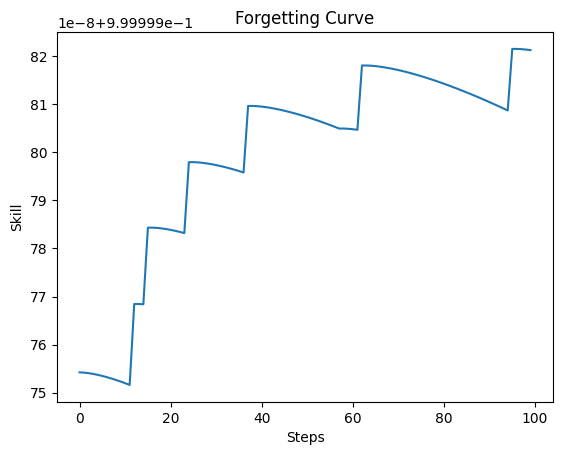

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from typing_env import TypingEnv


env = TypingEnv()
state = env.reset()

target_bigram = 39
difficulty = 3
action = target_bigram * env.L + difficulty

# forgetting curve experiment
env.reset()

learning_steps = 100
forget_steps = 100

forget_curve = []

# learn first
for step in range(learning_steps):
    state, reward, done, _ = env.step(action)

# stop practicing target bigram
for step in range(forget_steps):
    random_action = np.random.randint(0, env.K * env.L)
    state, reward, done, _ = env.step(31)
    forget_curve.append(env.k[target_bigram])

print(forget_curve)

plt.plot(forget_curve)
plt.title("Forgetting Curve")
plt.xlabel("Steps")
plt.ylabel("Skill")

plt.show()

In [7]:
import pandas as pd
df = pd.read_csv("typing_dataset.csv")
df.head()


,sentence,target_bigram,difficulty
0,the thin cat sat on the mat,th,0
1,this path has the moth on it,th,0
2,that cloth has both the moths,th,0
3,the bath with the thick cloth,th,0
4,both the teeth and the cloth,th,0


In [8]:

for i in range(20):
    j = i // 20
    if(i==0):
        print(f"for bigram {BIGRAM_BAG[j]}")
    sentence = df['sentence'][i]
    print(count_tracked_bigrams(sentence)[BIGRAM_BAG[j]])
    

for bigram th
3
4
5
6
5
5
5
5
5
5
5
5
5
6
5
5
5
5
5
5


In [9]:
import numpy as np
import matplotlib.pyplot as plt

from typing_env import TypingEnv

In [10]:
def run_random_agent(episodes=30, steps_per_episode=100):
    
    env = TypingEnv()
    
    K = env.K
    L = env.L
    
    all_rewards = []
    all_skills = []
    
    for ep in range(episodes):
        
        env.reset()
        
        episode_rewards = []
        episode_skills = []
        
        for step in range(steps_per_episode):
            
            action = np.random.randint(0, K * L)
            
            _, reward, _, _ = env.step(action)
            
            episode_rewards.append(reward)
            episode_skills.append(np.mean(env.k))
        
        all_rewards.append(np.mean(episode_rewards))
        all_skills.append(episode_skills[-1])  # final skill
        
    return all_rewards, all_skills

In [11]:
def select_action(env):
    
    scores = env.k - 0.1 * env.t
    weakest_bigram = np.argmin(scores)
    
    skill = env.k[weakest_bigram]
    
    if skill < 0.3:
        difficulty = 0
    elif skill < 0.5:
        difficulty = 1
    elif skill < 0.7:
        difficulty = 2
    elif skill < 0.85:
        difficulty = 3
    else:
        difficulty = 4
    
    return weakest_bigram * env.L + difficulty

In [12]:
def run_rule_agent(episodes=30, steps_per_episode=100):
    
    env = TypingEnv()
    
    all_rewards = []
    all_skills = []
    
    for ep in range(episodes):
        
        env.reset()
        
        episode_rewards = []
        episode_skills = []
        
        for step in range(steps_per_episode):
            
            action = select_action(env)
            
            _, reward, _, _ = env.step(action)
            
            episode_rewards.append(reward)
            episode_skills.append(np.mean(env.k))
        
        all_rewards.append(np.mean(episode_rewards))
        all_skills.append(episode_skills[-1])
        
    return all_rewards, all_skills

In [13]:
random_rewards, random_skills = run_random_agent()
rule_rewards, rule_skills = run_rule_agent()

Avg skill before: 0.2489094602864698
Avg skill after : 0.26444158966119036
Avg skill before: 0.26444158966119036
Avg skill after : 0.27154312537095826
Avg skill before: 0.27154312537095826
Avg skill after : 0.2768850197542959
Avg skill before: 0.2768850197542959
Avg skill after : 0.2886315537781026
Avg skill before: 0.2886315537781026
Avg skill after : 0.3003854979989645
Avg skill before: 0.3003854979989645
Avg skill after : 0.3193132825538688
Avg skill before: 0.3193132825538688
Avg skill after : 0.3282699112393198
Avg skill before: 0.3282699112393198
Avg skill after : 0.3414543394811616
Avg skill before: 0.3414543394811616
Avg skill after : 0.3561325963652573
Avg skill before: 0.3561325963652573
Avg skill after : 0.3675005118526283
Avg skill before: 0.3675005118526283
Avg skill after : 0.37776436087750576
Avg skill before: 0.37776436087750576
Avg skill after : 0.39181257154404586
Avg skill before: 0.39181257154404586
Avg skill after : 0.4027211397652309
Avg skill before: 0.4027211397

In [14]:
print("Random avg skill:", np.mean(random_skills))
print("Rule avg skill:", np.mean(rule_skills))

print("Random avg reward:", np.mean(random_rewards))
print("Rule avg reward:", np.mean(rule_rewards))

Random avg skill: 0.857199239221
Rule avg skill: 0.8471122492156868
Random avg reward: 0.21611038199642466
Rule avg reward: 0.13340980678532194


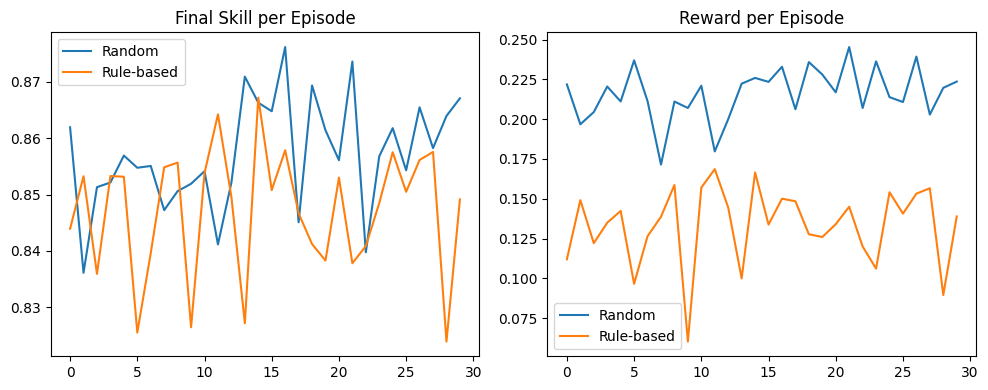

In [15]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(random_skills, label="Random")
plt.plot(rule_skills, label="Rule-based")
plt.title("Final Skill per Episode")
plt.legend()

plt.subplot(1,2,2)
plt.plot(random_rewards, label="Random")
plt.plot(rule_rewards, label="Rule-based")
plt.title("Reward per Episode")
plt.legend()

plt.tight_layout()
plt.show()

## test for q_learning agent

In [16]:
from q_learning import QLearningAgent

agent = QLearningAgent()

rewards, skills = agent.train(
    episodes=10,
    steps_per_episode=300
)

Avg skill before: 0.24869887953069142
Avg skill after : 0.2643601259619211
Avg skill before: 0.2643601259619211
Avg skill after : 0.2711670292638745
Avg skill before: 0.2711670292638745
Avg skill after : 0.2792600508809424
Avg skill before: 0.2792600508809424
Avg skill after : 0.29603651155792166
Avg skill before: 0.29603651155792166
Avg skill after : 0.30426328708820743
Avg skill before: 0.30426328708820743
Avg skill after : 0.3200395549346505
Avg skill before: 0.3200395549346505
Avg skill after : 0.33151796479178924
Avg skill before: 0.33151796479178924
Avg skill after : 0.34276062987966727
Avg skill before: 0.34276062987966727
Avg skill after : 0.35953347242906974
Avg skill before: 0.35953347242906974
Avg skill after : 0.3693407665341582
Avg skill before: 0.3693407665341582
Avg skill after : 0.37777169253051585
Avg skill before: 0.37777169253051585
Avg skill after : 0.3859198302369813
Avg skill before: 0.3859198302369813
Avg skill after : 0.40010766667414827
Avg skill before: 0.4001

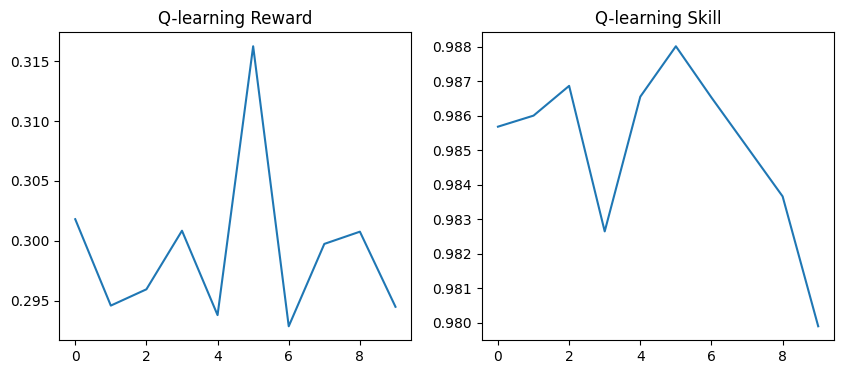

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(rewards)
plt.title("Q-learning Reward")

plt.subplot(1,2,2)
plt.plot(skills)
plt.title("Q-learning Skill")

plt.show()